# Detecting Crop Disease from Leaf Images


## Importing the Library


In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

## Connecting to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Augmentation (Preparing the data)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

In [ ]:
train_set = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Dataset",
    target_size = (150, 150),
    batch_size = 32,
    class_mode = "sparse",
    subset = "training"
    )

Found 1738 images belonging to 3 classes.


In [ ]:
val_set = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Dataset",
    target_size = (150, 150),
    batch_size = 32,
    class_mode = "sparse",
    subset = "validation"
    )

Found 433 images belonging to 3 classes.


## Building the model

In [ ]:
from tensorflow.keras import models, layers

**1st layer**
- filters/kernel -> 3*3 pixel filter and this is the kernel size.
- we will create 32 filter hare. filter works differently. but the basic work is to scan.
* 1st filter -> where is vein
* 2nd filter -> how much age
* 3rd filter -> is there any prominent color (brown)
and so on..

activation relu:
* if 1st filter get the negetive value. means he is unable to find patteren. then the information will not pass to the 2nd stage.

input shape:
* all image convert into 150 to 150 pixel and RGB(3) color format. so that we can scan better.

Maxpulling:
* after the filter we create the layer. later in maxpulling we again filter with 2*2 filter. By this avoid the unnecessery information.

* As the image is more or less same thats why we create many layers. if we just want to differentiate just the cat and dog. 2 layer will be enough.

!!! find out why more is bad....

In [ ]:
model = models.Sequential([
    # Layer-1: Detects basic edges and the veins of the leaf
    layers.Conv2D(filters=32, kernel_size = (3, 3), activation = 'relu', input_shape=(150, 150,3)),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Layer 2: Detects color blobs and spot pattern
    layers.Conv2D(filters=64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Layer 3: Complex shapes (like the halo around a fungus spot)
    layers.Conv2D(filters=128, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Flatten the 2D image into a 1D line to take the final decision
    layers.Flatten(),
    layers.Dense(units = 128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(units = 3, activation = 'softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compliling the model

In [ ]:
model.compile(
    optimizer='adam', # apaptive moment optimizer is an algorithm which work wt. loss and wt. gain process give importance to those feature.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

## Training the model

In [10]:
history = model.fit(
    train_set,
    epochs=10,
    validation_data=val_set
    )

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.5621 - loss: 0.9064 - val_accuracy: 0.7298 - val_loss: 0.6498
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7842 - loss: 0.5608 - val_accuracy: 0.7691 - val_loss: 0.5346
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8763 - loss: 0.3126 - val_accuracy: 0.9330 - val_loss: 0.2014
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9246 - loss: 0.1911 - val_accuracy: 0.8222 - val_loss: 0.4019
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9229 - loss: 0.2103 - val_accuracy: 0.9630 - val_loss: 0.1207
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9448 - loss: 0.1396 - val_accuracy: 0.9238 - val_loss: 0.2138
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9344 - loss: 0.1799 - val_accuracy: 0.9492 - val_loss: 0.1383
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9171 - loss: 0.2396 - val_accuracy: 0.9099 - val_loss

## Saving the model

In [12]:
model.save("potato_leaf_disease_model.keras")

## Re-using the AI brain

In [13]:
from tensorflow.keras.models import load_model

In [14]:
AI_brain = load_model("potato_leaf_disease_model.keras")

## AI Brain Evaluation

In [17]:
loss, accuracy = AI_brain.evaluate(val_set)
print(f"Reused model loss on validation set: {loss:.4f}")
print(f"Reused model accuracy on validation set: {accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 501ms/step - accuracy: 0.9376 - loss: 0.1768
Reused model loss on validation set: 0.1768
Reused model accuracy on validation set: 0.9376


NameError: name 'true_classes' is not defined

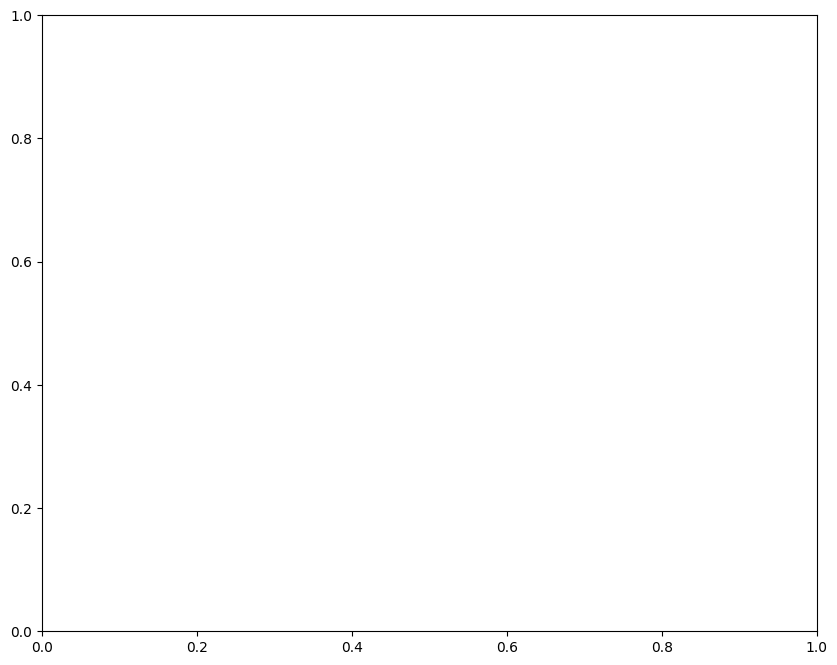

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Using ConfusionMatrixDisplay for a simpler plot
fig, ax = plt.subplots(figsize=(10, 8))
display_cm = ConfusionMatrixDisplay.from_predictions(
    y_true=true_classes,
    y_pred=predicted_classes,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title('Confusion Matrix')
plt.show()